### Pizza Place Sales Analysis

## Introduction
This project analyses one year of sales data from a fictitious pizza restaurant. The analysis examines revenue, quantity sold, customer orders, pizza varieties, peak sales periods, bestselling pizzas, montly sales trends, and underperforming products.

The dataset consists of four related tables:
- Orders
- Order Details
- Pizzas
- Pizza Types

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
import pandas as pd

order_details = pd.read_csv(
    r"C:\Users\USER\Desktop\DEKSTOP\Adex Documents\Data Science Training\Pizza Place Sales Project\order_details.csv"
)

orders = pd.read_csv(
    r"C:\Users\USER\Desktop\DEKSTOP\Adex Documents\Data Science Training\Pizza Place Sales Project\orders.csv"
)

pizza_types = pd.read_csv(
    r"C:\Users\USER\Desktop\DEKSTOP\Adex Documents\Data Science Training\Pizza Place Sales Project\pizza_types.csv",
    encoding="latin-1"
)

pizzas = pd.read_csv(
    r"C:\Users\USER\Desktop\DEKSTOP\Adex Documents\Data Science Training\Pizza Place Sales Project\pizzas.csv"
)

In [67]:
order_details.head()
orders.head()
pizza_types.head()
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [68]:
order_details.info()
orders.info()
pizza_types.info()
pizzas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-n

In [69]:
df = (order_details
      .merge(orders, on="order_id", how="left")
      .merge(pizzas, on="pizza_id", how="left")
      .merge(pizza_types, on="pizza_type_id", how="left"))


In [70]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [72]:
df.shape

(48620, 12)

## Data Inspection

The four datasets were merged into a single DataFrame containing 48,620 rows and 12 columns. The merged data was inspected to understand its structure, data types, missing values, and possible duplicates.

In [73]:
df.columns.tolist()

['order_details_id',
 'order_id',
 'pizza_id',
 'quantity',
 'date',
 'time',
 'pizza_type_id',
 'size',
 'price',
 'name',
 'category',
 'ingredients']

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [75]:
df.describe(include="all")

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
count,48620.000000,48620.000000,48620,48620.000000,48620,48620,48620,48620,48620.000000,48620,48620,48620
unique,NaN,NaN,91,NaN,358,16382,32,5,NaN,32,4,32
top,NaN,NaN,big_meat_s,NaN,2015-11-26,12:32:00,classic_dlx,L,NaN,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
freq,NaN,NaN,1811,NaN,261,26,2416,18526,NaN,2416,14579,2416
mean,24310.500000,10701.479761,NaN,1.019622,NaN,NaN,NaN,NaN,16.494132,NaN,NaN,NaN
std,14035.529381,6180.119770,NaN,0.143077,NaN,NaN,NaN,NaN,3.621789,NaN,NaN,NaN
min,1.000000,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,9.750000,NaN,NaN,NaN
25%,12155.750000,5337.000000,NaN,1.000000,NaN,NaN,NaN,NaN,12.750000,NaN,NaN,NaN
50%,24310.500000,10682.500000,NaN,1.000000,NaN,NaN,NaN,NaN,16.500000,NaN,NaN,NaN
75%,36465.250000,16100.000000,NaN,1.000000,NaN,NaN,NaN,NaN,20.250000,NaN,NaN,NaN


In [76]:
#to see the total number of missing values

df.isnull().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

### Insight
The merged dataset contained no missing values, indicating that all records were complete after the merge.

In [77]:
#to check duplicated rows

df.duplicated().sum()

0

In [78]:
df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date', 'time',
       'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients'],
      dtype='object')

## Data Preparation

The date and time columns were converted into appropriate formats. Additional variables were created for hour, day of the week, month, and revenue.

In [79]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [80]:
df["date"].dtype

dtype('<M8[ns]')

In [81]:
df["hour"] = pd.to_datetime(
    df["time"],
    format="%H:%M:%S",
    errors="coerce"
).dt.hour

In [82]:
df[["time", "hour"]].head()

,time,hour
0,11:38:36,11
1,11:57:40,11
2,11:57:40,11
3,11:57:40,11
4,11:57:40,11


In [83]:
df["day_name"] = df["date"].dt.day_name()
df["month_name"] = df["date"].dt.month_name()
df["month_number"] = df["date"].dt.month

In [84]:
df[["date", "day_name", "month_name", "month_number"]].head()

,date,day_name,month_name,month_number
0,2015-01-01,Thursday,January,1
1,2015-01-01,Thursday,January,1
2,2015-01-01,Thursday,January,1
3,2015-01-01,Thursday,January,1
4,2015-01-01,Thursday,January,1


In [85]:
#creating the revenue column
#Revenue is quantity multipled by price

df["revenue"] = df["quantity"] * df["price"]

In [86]:
df[["quantity", "price", "revenue"]].head()

,quantity,price,revenue
0,1,13.25,13.25
1,1,16.00,16.00
2,1,18.50,18.50
3,1,20.75,20.75
4,1,16.00,16.00


## 1. Total Revenue
Total revenue was calculated by multiplying the quantity sold by the unit price for each transaction and summing the resulting values.

In [87]:
total_revenue = df["revenue"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


### Insight
The pizza restaurant generated total revenue of $817,860.05 during the year.

## 2. Total Quantity Sold

In [88]:
total_quantity = df["quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 49,574


### Insight
A total of 49,574 pizzas were sold during the year.

## 3. Total Number of Orders

In [89]:
total_orders = df["order_id"].nunique()

print(f"Total Number of Orders: {total_orders:,}")

Total Number of Orders: 21,350


## Insight
The total number of Orders is 21,350

## 4. Number of Pizza Types

In [90]:
total_pizza_types = df["pizza_type_id"].nunique()

print("Number of Pizza Types:", total_pizza_types)

Number of Pizza Types: 32


## Insight
The total number of Pizza types is 32

In [91]:
df["name"].drop_duplicates().sort_values().tolist()

['The Barbecue Chicken Pizza',
 'The Big Meat Pizza',
 'The Brie Carre Pizza',
 'The Calabrese Pizza',
 'The California Chicken Pizza',
 'The Chicken Alfredo Pizza',
 'The Chicken Pesto Pizza',
 'The Classic Deluxe Pizza',
 'The Five Cheese Pizza',
 'The Four Cheese Pizza',
 'The Greek Pizza',
 'The Green Garden Pizza',
 'The Hawaiian Pizza',
 'The Italian Capocollo Pizza',
 'The Italian Supreme Pizza',
 'The Italian Vegetables Pizza',
 'The Mediterranean Pizza',
 'The Mexicana Pizza',
 'The Napolitana Pizza',
 'The Pepper Salami Pizza',
 'The Pepperoni Pizza',
 'The Pepperoni, Mushroom, and Peppers Pizza',
 'The Prosciutto and Arugula Pizza',
 'The Sicilian Pizza',
 'The Soppressata Pizza',
 'The Southwest Chicken Pizza',
 'The Spicy Italian Pizza',
 'The Spinach Pesto Pizza',
 'The Spinach Supreme Pizza',
 'The Spinach and Feta Pizza',
 'The Thai Chicken Pizza',
 'The Vegetables + Vegetables Pizza']

## 5. Average Pizza Price

In [92]:
average_price = df[["pizza_id", "price"]].drop_duplicates()["price"].mean()

print(f"Average Pizza Price: ${average_price:.2f}")

Average Pizza Price: $16.51


## Insight
The average pizza price is $16.51

In [93]:
#calculating the actual average selling price per pizza sold

average_selling_price = total_revenue / total_quantity

print(f"Average Selling Price per Pizza: ${average_selling_price:.2f}")

Average Selling Price per Pizza: $16.50


## 6. Peak Hours of Sales
Peak sales hours were examined using both the number of unique orders and total revenue generated during each hour.

In [94]:
#calculating unique orders by hour

hourly_orders = (
    df.groupby("hour")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False))

hourly_orders.head(10)

,hour,total_orders
3,12,2520
4,13,2455
9,18,2399
8,17,2336
10,19,2009
7,16,1920
11,20,1642
5,14,1472
6,15,1468
2,11,1231


In [95]:
#finding the peak hour

peak_hour = hourly_orders.iloc[0]

print("Peak Hour:", int(peak_hour["hour"]))
print("Number of Orders:", int(peak_hour["total_orders"]))

Peak Hour: 12
Number of Orders: 2520


In [96]:
#calculating revenue by hour

hourly_revenue = (
    df.groupby("hour")["revenue"]
    .sum()
    .reset_index()
    .sort_values("hour"))

hourly_revenue

,hour,revenue
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


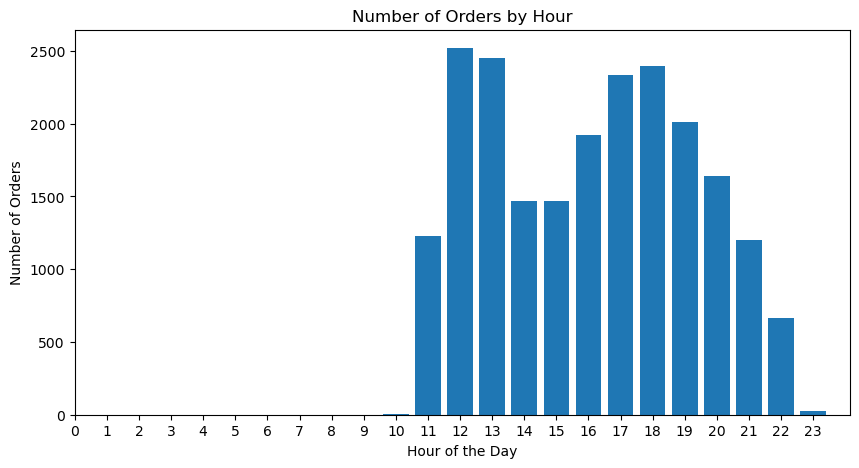

In [97]:
#creating a histogram chart

hourly_orders_chart = hourly_orders.sort_values("hour")

plt.figure(figsize=(10, 5))
plt.bar(
    hourly_orders_chart["hour"],
    hourly_orders_chart["total_orders"])

plt.title("Number of Orders by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0, 24))
plt.show()

## 7. Sales by Day of the Week

In [98]:
#setting the correct day order

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [99]:
daily_sales = (df.groupby("day_name")["revenue"]
               .sum()
               .reindex(day_order)
               .reset_index())
daily_sales

,day_name,revenue
0,Monday,107329.55
1,Tuesday,114133.80
2,Wednesday,114408.40
3,Thursday,123528.50
4,Friday,136073.90
5,Saturday,123182.40
6,Sunday,99203.50


In [100]:
#finding the highest sales day

highest_sales_day = daily_sales.loc[daily_sales["revenue"].idxmax()]

print("Day with Highest Sales:", highest_sales_day["day_name"])
print(f"Sales Amount: ${highest_sales_day['revenue']:,.2f}")

Day with Highest Sales: Friday
Sales Amount: $136,073.90


## Insight
- Day with the highest sales is Friday
- And the sales amount for that day (Friday) is $136,073.90


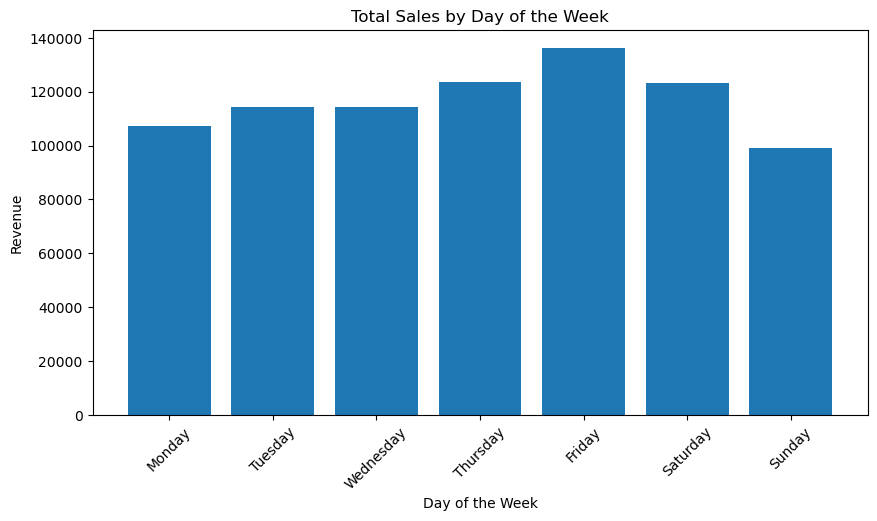

In [101]:
#Plot

plt.figure(figsize=(10, 5))
plt.bar(daily_sales["day_name"], daily_sales["revenue"])

plt.title("Total Sales by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 8. Top Five Bestselling Pizzas

Bestselling pizzas were identified using the total quantity sold.

In [102]:
top_five_pizzas = (df.groupby("name")["quantity"]
                   .sum()
                   .sort_values(ascending=False)
                   .head(5)
                   .reset_index())

top_five_pizzas

,name,quantity
0,The Classic Deluxe Pizza,2453
1,The Barbecue Chicken Pizza,2432
2,The Hawaiian Pizza,2422
3,The Pepperoni Pizza,2418
4,The Thai Chicken Pizza,2371


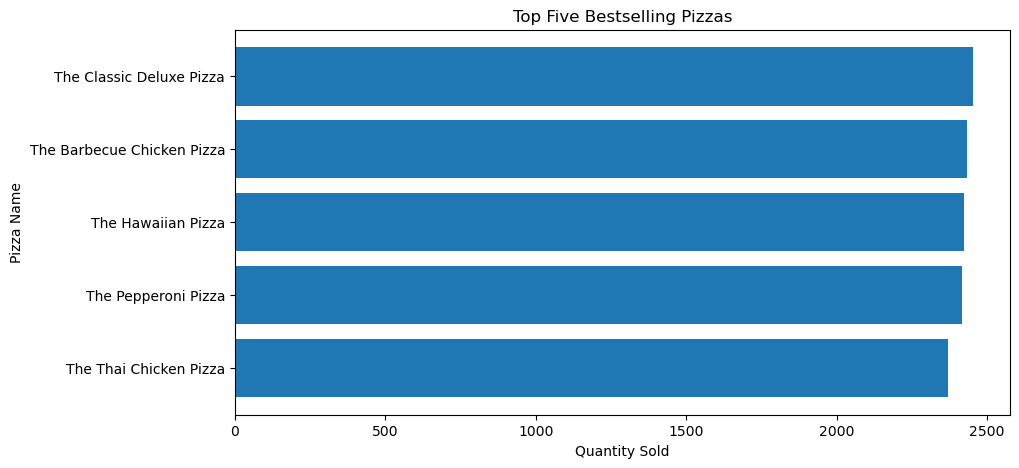

In [103]:
#Plot (visualization)

plt.figure(figsize=(10, 5))
plt.barh(top_five_pizzas["name"], top_five_pizzas["quantity"])

plt.title("Top Five Bestselling Pizzas")
plt.xlabel("Quantity Sold")
plt.ylabel("Pizza Name")
plt.gca().invert_yaxis()
plt.show()

## 9. Monthly Sales Trend

In [104]:
monthly_sales = (df.groupby(["month_number", "month_name"])["revenue"]
                 .sum()
                 .reset_index()
                 .sort_values("month_number"))

monthly_sales

,month_number,month_name,revenue
0,1,January,69793.30
1,2,February,65159.60
2,3,March,70397.10
3,4,April,68736.80
4,5,May,71402.75
5,6,June,68230.20
6,7,July,72557.90
7,8,August,68278.25
8,9,September,64180.05
9,10,October,64027.60


In [105]:
#finding highest and lowest months

highest_month = monthly_sales.loc[monthly_sales["revenue"].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales["revenue"].idxmin()]

print("Highest Sales Month:", highest_month["month_name"])
print(f"Revenue: ${highest_month['revenue']:,.2f}")

print("\nLowest Sales Month:", lowest_month["month_name"])
print(f"Revenue: ${lowest_month['revenue']:,.2f}")

Highest Sales Month: July
Revenue: $72,557.90

Lowest Sales Month: October
Revenue: $64,027.60


## Insight
- The highest sales month is July, with a revenue generation of $72,557.90
  
- The lowest sales month is October, with a revenue generation of $64,027.60

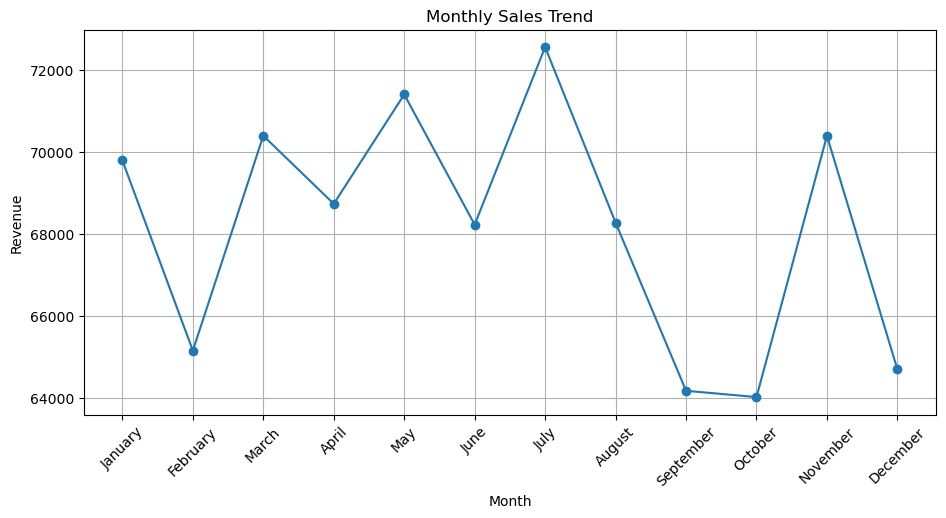

In [106]:
#plot

plt.figure(figsize=(11, 5))
plt.plot(monthly_sales["month_name"], monthly_sales["revenue"], marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Insight
According to the monthly sales trend above, the sales for each month is not stable, is fluctuating.

## 10. Underperforming Pizza Types

Underperforming pizzas were identified using low quantity sold, low revenue, and low order frequency.

In [107]:
pizza_performance = (df.groupby("name").agg
                     (total_quantity=("quantity", "sum"),
                      total_revenue=("revenue", "sum"),
                      total_orders=("order_id", "nunique"))
                     .reset_index())

In [108]:
#display the weakest pizzas

bottom_pizzas = pizza_performance.sort_values(["total_quantity", "total_revenue"]).head(10)

bottom_pizzas

,name,total_quantity,total_revenue,total_orders
2,The Brie Carre Pizza,490,11588.50,480
16,The Mediterranean Pizza,934,15360.50,912
3,The Calabrese Pizza,937,15934.25,918
28,The Spinach Supreme Pizza,950,15277.75,918
24,The Soppressata Pizza,961,16425.75,941
27,The Spinach Pesto Pizza,970,15596.00,945
6,The Chicken Pesto Pizza,973,16701.75,938
15,The Italian Vegetables Pizza,981,16019.25,952
5,The Chicken Alfredo Pizza,987,16900.25,967
11,The Green Garden Pizza,997,13955.75,976


In [109]:
#bottom five by revenue

bottom_five_revenue = (pizza_performance.sort_values("total_revenue").head(5))

bottom_five_revenue

,name,total_quantity,total_revenue,total_orders
2,The Brie Carre Pizza,490,11588.50,480
11,The Green Garden Pizza,997,13955.75,976
28,The Spinach Supreme Pizza,950,15277.75,918
16,The Mediterranean Pizza,934,15360.50,912
27,The Spinach Pesto Pizza,970,15596.00,945


## Additional Analysis: Sales by Pizza Category

In [110]:
category_sales = (df.groupby("category").agg(total_quantity=("quantity", "sum"), total_revenue=("revenue", "sum"))
                  .reset_index()
                  .sort_values("total_revenue", ascending=False))

category_sales

,category,total_quantity,total_revenue
1,Classic,14888,220053.10
2,Supreme,11987,208197.00
0,Chicken,11050,195919.50
3,Veggie,11649,193690.45


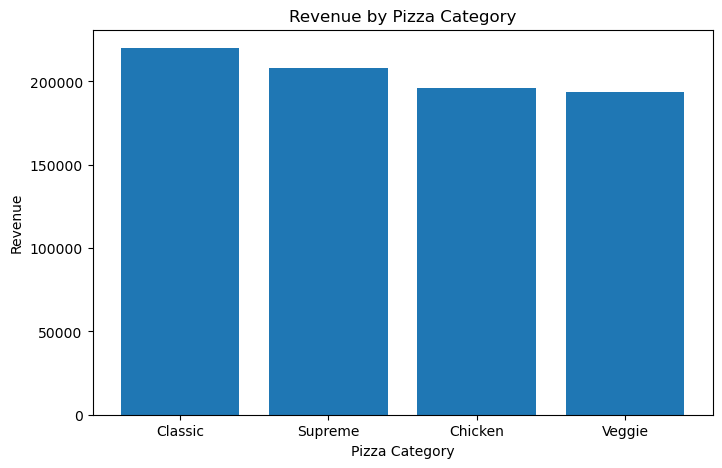

In [111]:
#plot

plt.figure(figsize=(8, 5))
plt.bar(category_sales["category"],
        category_sales["total_revenue"])

plt.title("Revenue by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Revenue")
plt.show()

## Additional Analysis: Sales by Pizza Size

In [112]:
size_sales = (df.groupby("size").agg(total_quantity=("quantity", "sum"),
                                     total_revenue=("revenue", "sum"))
              .reset_index()
              .sort_values("total_quantity", ascending=False))

size_sales

,size,total_quantity,total_revenue
0,L,18956,375318.70
1,M,15635,249382.25
2,S,14403,178076.50
3,XL,552,14076.00
4,XXL,28,1006.60


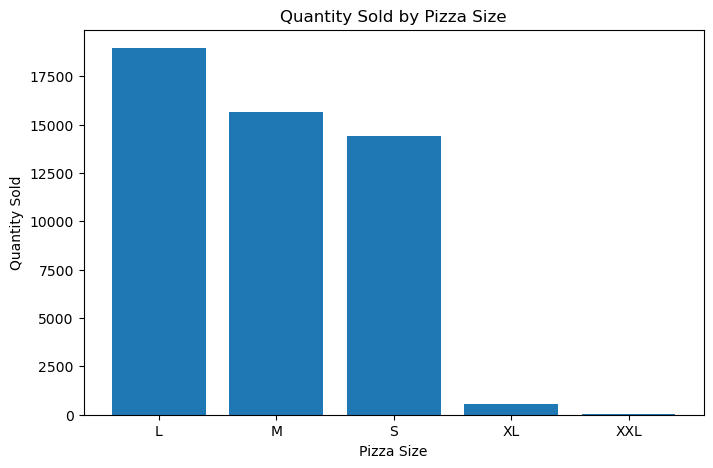

In [113]:
plt.figure(figsize=(8, 5))
plt.bar(size_sales["size"], size_sales["total_quantity"])

plt.title("Quantity Sold by Pizza Size")
plt.xlabel("Pizza Size")
plt.ylabel("Quantity Sold")
plt.show()

## Additional Analysis: Average Order Value

In [114]:
revenue_per_order = df.groupby("order_id")["revenue"].sum()

average_order_value = revenue_per_order.mean()

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $38.31


## Additional Analysis: Average Pizzas per Order

In [115]:
quantity_per_order = df.groupby("order_id")["quantity"].sum()

average_pizzas_per_order = quantity_per_order.mean()

print(f"Average Pizzas per Order: {average_pizzas_per_order:.2f}")

Average Pizzas per Order: 2.32


 ## Additional Analysis
 - Bestselling Pizza
 - Weakest Performing Pizza
 - Best-Performing Category
 - Most Popular Pizza Size

In [116]:
#Best selling pizza

best_pizza = (df.groupby("name")["quantity"]
    .sum()
    .sort_values(ascending=False))

print(best_pizza.head(1))

name
The Classic Deluxe Pizza    2453
Name: quantity, dtype: int64


In [117]:
#Weakest-performing pizza

weakest_pizza = (df.groupby("name")["quantity"]
    .sum()
    .sort_values())

print(weakest_pizza.head(1))

name
The Brie Carre Pizza    490
Name: quantity, dtype: int64


In [118]:
#Best performing category

best_category = (df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False))

print(best_category)

category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: revenue, dtype: float64


In [119]:
#Most popular pizza size

popular_size = (df.groupby("size")["quantity"]
    .sum()
    .sort_values(ascending=False))

print(popular_size)

size
L      18956
M      15635
S      14403
XL       552
XXL       28
Name: quantity, dtype: int64


## Final Summary

In [120]:
print("PIZZA PLACE SALES SUMMARY")
print("-" * 45)
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Number of Pizza Types: {total_pizza_types}")
print(f"Average Pizza Price: ${average_price:.2f}")
print(f"Average Selling Price: ${average_selling_price:.2f}")
print(f"Average Order Value: ${average_order_value:.2f}")
print(f"Average Pizzas per Order: {average_pizzas_per_order:.2f}")
print(f"Highest Sales Day: {highest_sales_day['day_name']}")
print(f"Highest Sales Month: {highest_month['month_name']}")
print(f"Peak Sales Hour: {int(peak_hour['hour'])}:00")
print(f"Bestselling Pizza: {best_pizza.index[0]}")
print(f"Weakest-performing Pizza: {weakest_pizza.index[0]}")
print(f"Best-performing Category: {best_category.index[0]}")
print(f"Most Popular Size: {popular_size.index[0]}")

PIZZA PLACE SALES SUMMARY
---------------------------------------------
Total Revenue: $817,860.05
Total Quantity Sold: 49,574
Total Orders: 21,350
Number of Pizza Types: 32
Average Pizza Price: $16.51
Average Selling Price: $16.50
Average Order Value: $38.31
Average Pizzas per Order: 2.32
Highest Sales Day: Friday
Highest Sales Month: July
Peak Sales Hour: 12:00
Bestselling Pizza: The Classic Deluxe Pizza
Weakest-performing Pizza: The Brie Carre Pizza
Best-performing Category: Classic
Most Popular Size: L


## Conclusion

The analysis examined one year of pizza sales using a merged dataset containing 48,620 transaction records. It assessed total revenue, quantity sold, number of orders, pizza varieties, average pricing, peak sales hours, weekly and monthly patterns, bestselling pizzas, and underperforming menu items.

The major findings showed that:

- Total revenue was $817,860.05.
- Total quantity sold was 49,574 pizzas.
- Total number of orders was 21,350.
- The peak sales hour was 12:00.
- The day with the highest sales was Friday.
- The month with the highest sales was July.
- The bestselling pizza was The Classic Deluxe Pizza.
- The weakest-performing pizza was The Brie Carre Pizza.
- The best-performing category was Classic.
- The most popular size was L.

The restaurant should ensure adequate staffing and inventory during peak hours and high-demand days. Management should also review underperforming pizzas and consider targeted promotions, menu adjustments, or product removal, as needed.